In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from plotnine import *
import matplotlib.pylab as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_curve, auc, precision_score, recall_score, f1_score

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s5e11/sample_submission.csv
/kaggle/input/competitions/playground-series-s5e11/train.csv
/kaggle/input/competitions/playground-series-s5e11/test.csv


In [2]:
train_df=pd.read_csv("/kaggle/input/competitions/playground-series-s5e11/train.csv")
test_df=pd.read_csv("/kaggle/input/competitions/playground-series-s5e11/test.csv")

In [3]:
train_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [4]:
test_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade
0,593994,28781.05,0.049,626,11461.42,14.73,Female,Single,High School,Employed,Other,D5
1,593995,46626.39,0.093,732,15492.25,12.85,Female,Married,Master's,Employed,Other,C1
2,593996,54954.89,0.367,611,3796.41,13.29,Male,Single,Bachelor's,Employed,Debt consolidation,D1
3,593997,25644.63,0.110,671,6574.30,9.57,Female,Single,Bachelor's,Employed,Debt consolidation,C3
4,593998,25169.64,0.081,688,17696.89,12.80,Female,Married,PhD,Employed,Business,C1


In [5]:
print(train_df.info())

print("...................................................................")

print(train_df.describe())

print("...................................................................")

print(train_df.shape)

print("...................................................................")

print(train_df["loan_paid_back"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 593994 entries, 0 to 593993
Data columns (total 13 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    593994 non-null  int64  
 1   annual_income         593994 non-null  float64
 2   debt_to_income_ratio  593994 non-null  float64
 3   credit_score          593994 non-null  int64  
 4   loan_amount           593994 non-null  float64
 5   interest_rate         593994 non-null  float64
 6   gender                593994 non-null  object 
 7   marital_status        593994 non-null  object 
 8   education_level       593994 non-null  object 
 9   employment_status     593994 non-null  object 
 10  loan_purpose          593994 non-null  object 
 11  grade_subgrade        593994 non-null  object 
 12  loan_paid_back        593994 non-null  float64
dtypes: float64(5), int64(2), object(6)
memory usage: 58.9+ MB
None
.........................................

In [6]:
print(test_df.info())

print("...................................................................")

print(test_df.describe())

print("...................................................................")

print(test_df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 254569 entries, 0 to 254568
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    254569 non-null  int64  
 1   annual_income         254569 non-null  float64
 2   debt_to_income_ratio  254569 non-null  float64
 3   credit_score          254569 non-null  int64  
 4   loan_amount           254569 non-null  float64
 5   interest_rate         254569 non-null  float64
 6   gender                254569 non-null  object 
 7   marital_status        254569 non-null  object 
 8   education_level       254569 non-null  object 
 9   employment_status     254569 non-null  object 
 10  loan_purpose          254569 non-null  object 
 11  grade_subgrade        254569 non-null  object 
dtypes: float64(4), int64(2), object(6)
memory usage: 23.3+ MB
None
...................................................................
                  id  ann

In [7]:
train_df['loan_to_income_ratio'] = train_df['loan_amount'] / (train_df['annual_income'] + 1)

In [8]:
test_df['loan_to_income_ratio'] = test_df['loan_amount'] / (test_df['annual_income'] + 1)


In [9]:
train_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,loan_to_income_ratio
0,0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0,0.086091
1,1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0,0.207748
2,2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0,0.343073
3,3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0,0.099926
4,4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0,0.477864


In [10]:
le=LabelEncoder()

cat_cols=train_df[["gender","marital_status","education_level","employment_status","loan_purpose","grade_subgrade"]]

for col in cat_cols:
    train_df[col]=le.fit_transform(train_df[col])

In [11]:
le=LabelEncoder()

cat_cols=test_df[["gender","marital_status","education_level","employment_status","loan_purpose","grade_subgrade"]]

for col in cat_cols:
    test_df[col]=le.fit_transform(test_df[col])

In [12]:
train_df.head()

,id,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,loan_to_income_ratio
0,0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,12,1.0,0.086091
1,1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,17,0.0,0.207748
2,2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,14,1.0,0.343073
3,3,46858.25,0.065,533,4682.48,16.10,0,2,1,0,2,25,1.0,0.099926
4,4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,15,1.0,0.477864


In [13]:
train_df.drop(["id"],axis=1,inplace=True)

In [14]:
train_df.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back,loan_to_income_ratio
0,29367.99,0.084,736,2528.42,13.67,0,2,1,2,6,12,1.0,0.086091
1,22108.02,0.166,636,4593.10,12.92,1,1,2,0,2,17,0.0,0.207748
2,49566.20,0.097,694,17005.15,9.76,1,2,1,0,2,14,1.0,0.343073
3,46858.25,0.065,533,4682.48,16.10,0,2,1,0,2,25,1.0,0.099926
4,25496.70,0.053,665,12184.43,10.21,1,1,1,0,6,15,1.0,0.477864


In [15]:
X=train_df.drop("loan_paid_back",axis=1)
y=train_df["loan_paid_back"]

In [16]:
print(f"X: {X.shape}, \nY: {y.shape}")

X: (593994, 12), 
Y: (593994,)


In [17]:
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [18]:
model= RandomForestClassifier(n_estimators=300,
                             random_state=42,
                             max_features="sqrt",
                             max_depth=10,
                             min_samples_split=5,
                             n_jobs=-1,
                             class_weight="balanced",
                             oob_score=True)

model.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_split=5, n_estimators=300, n_jobs=-1,
                       oob_score=True, random_state=42)

In [19]:
Train= model.score(X_train,y_train)
Test=model.score(X_val,y_val)

print(f"Train Score: {Train:.2%}, \nTest Score: {Test:.2%}, \nOOB:{model.oob_score_:.2%}")


for name, mdl in [("MODEL",model)]:
    print(f"\n--- {name} Report ---")
    print(classification_report(
        y_val, mdl.predict(X_val),
        target_names=['Paid back','Not Paid back']))

Train Score: 86.81%, 
Test Score: 86.46%, 
OOB:86.53%

--- MODEL Report ---
               precision    recall  f1-score   support

    Paid back       0.63      0.77      0.70     23900
Not Paid back       0.94      0.89      0.91     94899

     accuracy                           0.86    118799
    macro avg       0.79      0.83      0.80    118799
 weighted avg       0.88      0.86      0.87    118799



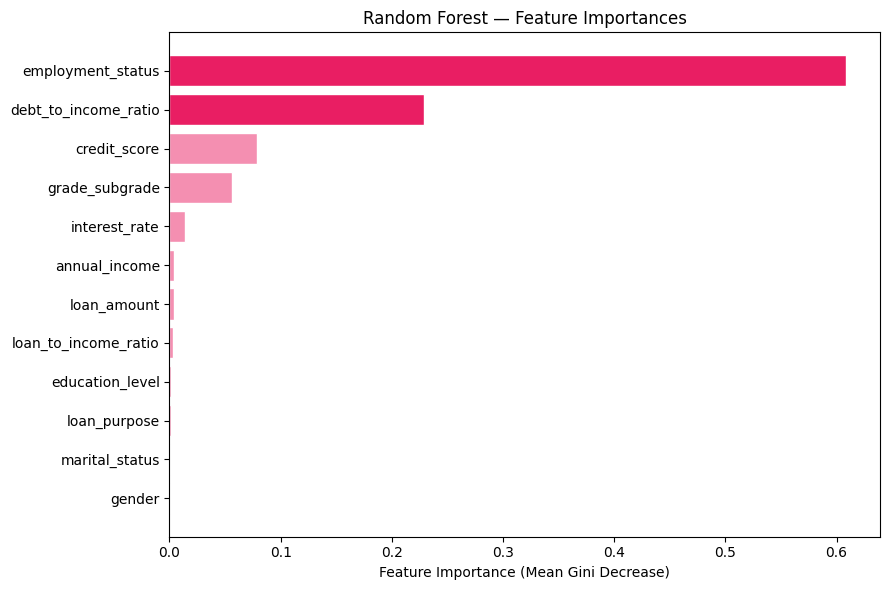

In [20]:
#Get importances
importances   = model.feature_importances_
feature_names = X.columns.tolist()

# Sort descending
idx = np.argsort(importances)[::-1]
sorted_names  = [feature_names[i] for i in idx]
sorted_values = importances[idx]

# Horizontal bar chart
plt.figure(figsize=(9, 6))
colors = ['#E91E63' if v > 0.08
          else '#F48FB1'
          for v in sorted_values]
plt.barh(sorted_names[::-1],
         sorted_values[::-1],
         color=colors[::-1],
         edgecolor='white')
plt.xlabel("Feature Importance (Mean Gini Decrease)")
plt.title("Random Forest — Feature Importances")
plt.tight_layout()
plt.show()



In [21]:
predictions = model.predict(test_df.drop(columns=["id"]))


In [22]:
#Create Submission File
submission=pd.DataFrame({
    "id":test_df["id"],
    "Churn":predictions
})

submission.to_csv("submission.csv",index=False)

In [23]:
submission.head()

,id,Churn
0,593994,1.0
1,593995,1.0
2,593996,0.0
3,593997,1.0
4,593998,1.0
